### Resolucion de Actividad Individual 2
___
##### Rubiolo, Pedro Ignacio
##### 15 Marzo 2026
##### Dataset: [F1 Drivers Dataset](https://www.kaggle.com/datasets/petalme/f1-drivers-dataset)
___

In [1]:
# Cargamos las librerias necesarias
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import statsmodels.api as sm

In [2]:
# Leemos los datos del .csv
df = pd.read_csv("./F1Drivers_Dataset.csv")
df.head(2)

,Driver,Nationality,Seasons,Championships,Race_Entries,Race_Starts,Pole_Positions,Race_Wins,Podiums,Fastest_Laps,...,Championship Years,Decade,Pole_Rate,Start_Rate,Win_Rate,Podium_Rate,FastLap_Rate,Points_Per_Entry,Years_Active,Champion
0,Carlo Abate,Italy,"[1962, 1963]",0.0,3.0,0.0,0.0,0.0,0.0,0.0,...,NaN,1960,0.0,0.0,0.0,0.0,0.0,0.0,2,False
1,George Abecassis,United Kingdom,"[1951, 1952]",0.0,2.0,2.0,0.0,0.0,0.0,0.0,...,NaN,1950,0.0,1.0,0.0,0.0,0.0,0.0,2,False


In [3]:
# Analizamos la composicion del dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 868 entries, 0 to 867
Data columns (total 22 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Driver              868 non-null    object 
 1   Nationality         868 non-null    object 
 2   Seasons             868 non-null    object 
 3   Championships       868 non-null    float64
 4   Race_Entries        868 non-null    float64
 5   Race_Starts         868 non-null    float64
 6   Pole_Positions      868 non-null    float64
 7   Race_Wins           868 non-null    float64
 8   Podiums             868 non-null    float64
 9   Fastest_Laps        868 non-null    float64
 10  Points              868 non-null    float64
 11  Active              868 non-null    bool   
 12  Championship Years  34 non-null     object 
 13  Decade              868 non-null    int64  
 14  Pole_Rate           868 non-null    float64
 15  Start_Rate          868 non-null    float64
 16  Win_Rate

___
Podemos obtener la sigueinte informacion del dataset:
- Esta compuesto por 22 columnas y 868 Filas
- Dentro de sus columnas encontramos `floats`, `bools`, `ints` y `objects`
- El indice es numerico, bien podria ser el nombre del piloto
- La unica columna incompleta es la de `Championship Years`
___

In [4]:
# Usamos Nombre de piloto como indice para acelerar posibles busquedas
# Primero nos asegurmaos de que sean unicos
rows, cols = df.shape 
if df["Driver"].nunique() == rows:
    txt = "No se repiten pilotos, es seguro"
    df = df.set_index("Driver")
else:
    txt = "Hay pilotos repetidos"
print(txt)
df.head(2)

No se repiten pilotos, es seguro


,Nationality,Seasons,Championships,Race_Entries,Race_Starts,Pole_Positions,Race_Wins,Podiums,Fastest_Laps,Points,...,Championship Years,Decade,Pole_Rate,Start_Rate,Win_Rate,Podium_Rate,FastLap_Rate,Points_Per_Entry,Years_Active,Champion
Driver,,,,,,,,,,,,,,,,,,,,,
Carlo Abate,Italy,"[1962, 1963]",0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,1960,0.0,0.0,0.0,0.0,0.0,0.0,2,False
George Abecassis,United Kingdom,"[1951, 1952]",0.0,2.0,2.0,0.0,0.0,0.0,0.0,0.0,...,NaN,1950,0.0,1.0,0.0,0.0,0.0,0.0,2,False


In [5]:
#Check para ver si anduvo
df.loc["Juan Manuel Fangio"]

Nationality                                                  Argentina
Seasons               [1950, 1951, 1953, 1954, 1955, 1956, 1957, 1958]
Championships                                                      5.0
Race_Entries                                                      52.0
Race_Starts                                                       51.0
Pole_Positions                                                    29.0
Race_Wins                                                         24.0
Podiums                                                           35.0
Fastest_Laps                                                      23.0
Points                                                           245.0
Active                                                           False
Championship Years                      [1951, 1954, 1955, 1956, 1957]
Decade                                                            1950
Pole_Rate                                                     0.557692
Start_

In [6]:
#Calculamos metricas con describe para iniciar el analisis
df.describe()

,Championships,Race_Entries,Race_Starts,Pole_Positions,Race_Wins,Podiums,Fastest_Laps,Points,Decade,Pole_Rate,Start_Rate,Win_Rate,Podium_Rate,FastLap_Rate,Points_Per_Entry,Years_Active
count,868.000000,868.000000,868.000000,868.000000,868.000000,868.000000,868.000000,868.000000,868.000000,868.000000,868.000000,868.000000,868.000000,868.000000,868.000000,868.000000
mean,0.084101,29.917051,27.694700,1.244240,1.247696,3.756912,1.261521,55.849459,1972.223502,0.011471,0.779824,0.011050,0.041389,0.011894,0.479158,3.664747
std,0.524883,53.780150,52.876476,6.347512,6.491921,14.432826,5.413644,265.968614,20.201084,0.046544,0.324303,0.043579,0.106457,0.043514,1.213826,3.501761
min,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,0.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1960.000000,0.000000,0.666667,0.000000,0.000000,0.000000,0.000000,1.000000
50%,0.000000,7.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1970.000000,0.000000,0.962251,0.000000,0.000000,0.000000,0.000000,2.000000
75%,0.000000,29.250000,26.000000,0.000000,0.000000,0.000000,0.000000,8.000000,1982.500000,0.000000,1.000000,0.000000,0.000000,0.000000,0.382517,5.000000
max,7.000000,359.000000,356.000000,103.000000,103.000000,191.000000,77.000000,4415.500000,2020.000000,0.557692,1.000000,0.461538,1.000000,0.500000,14.197749,19.000000


In [7]:
#Ajustamos los datatypes para que sea un poco mas eficiente el analisis
df['Championships'] = df['Championships'].astype(int)
df['Race_Entries'] = df['Race_Entries'].astype(int)
df['Race_Starts'] = df['Race_Starts'].astype(int)
df['Pole_Positions'] = df['Pole_Positions'].astype(int)
df['Race_Wins'] = df['Race_Wins'].astype(int)
df['Podiums'] = df['Podiums'].astype(int)
df['Fastest_Laps'] = df['Fastest_Laps'].astype(int)
df['Nationality'] = df['Nationality'].astype('category')

df.dtypes


Nationality           category
Seasons                 object
Championships            int64
Race_Entries             int64
Race_Starts              int64
Pole_Positions           int64
Race_Wins                int64
Podiums                  int64
Fastest_Laps             int64
Points                 float64
Active                    bool
Championship Years      object
Decade                   int64
Pole_Rate              float64
Start_Rate             float64
Win_Rate               float64
Podium_Rate            float64
FastLap_Rate           float64
Points_Per_Entry       float64
Years_Active             int64
Champion                  bool
dtype: object

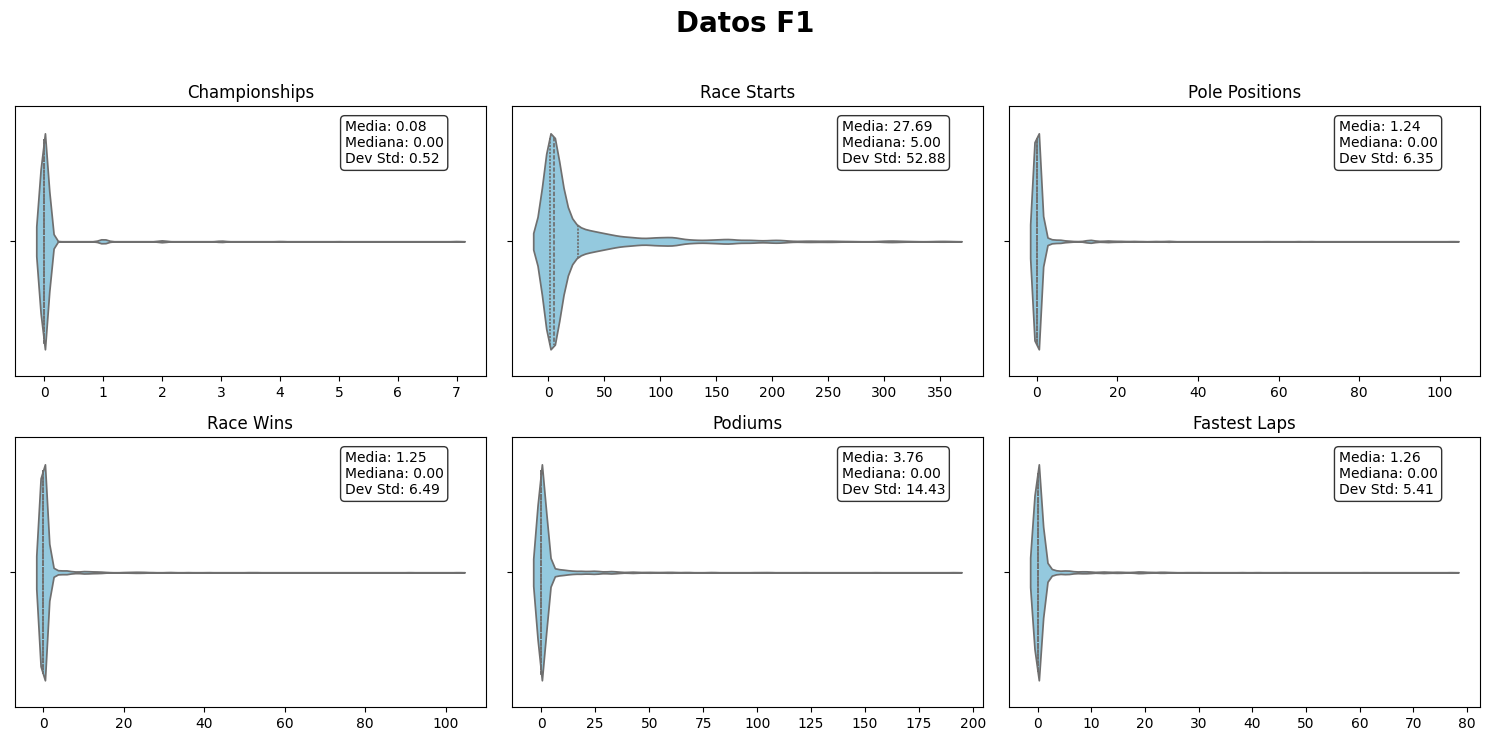

In [8]:
#Veamos como se distribuyen las variables numericas mas relevantes
#Championships, Starts, Poles, Wins, Podiums, Fastest Laps
def my_violins(column_name, plotting_ax):
    sns.violinplot(
        x=df[column_name], 
        inner='quart', 
        bw_adjust=0.5, 
        color="skyblue", 
        ax=plotting_ax  
    )

    plotting_ax.set_title(column_name.replace('_', ' '))
    plotting_ax.set_xlabel("")

    mean_val = df[column_name].mean()
    median_val = df[column_name].median()
    std_val = df[column_name].std()

    stats_text = (f'Media: {mean_val:.2f}\n'
                  f'Mediana: {median_val:.2f}\n'
                  f'Dev Std: {std_val:.2f}')
    
    plotting_ax.text(0.7, 0.95, stats_text, transform=plotting_ax.transAxes, 
                    fontsize=10, verticalalignment='top',horizontalalignment='left',
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    plotting_ax.set_xlabel("")
    plotting_ax.set_ylabel("")

fig, ax = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("Datos F1", fontsize=20, y=0.95, fontweight='bold')
my_violins("Championships", ax[0][0])
my_violins("Race_Starts",   ax[0][1])
my_violins("Pole_Positions",ax[0][2])
my_violins("Race_Wins",     ax[1][0])
my_violins("Podiums",       ax[1][1])
my_violins("Fastest_Laps",  ax[1][2])

plt.tight_layout(rect=[0, 0.03, 1, 0.93])
plt.show()



___
De estas graficas podemos ver que:
- En todos casos, los valores extremos se asocian a los pilotos "Fuera de Serie", siendo
resultado de la naturaleza del deporte, en que los pilotos exitosos son un porcentaje muy bajo.
- En cada grafico podemos entender las expectativas de un corredor normal, que implican no ganar carreras campeonatos,podios, poles o vueltas rapidas.
- Es complicado decidir la cantidad de carreras en las que participara un piloto, ya que la media y la mediana aportan valores muy dispares. Siendo la mediana un estadistico robusto, opto por decir que se espera que participe en 5 carreras, pero aun asi considero que se debe reanalizar discriminando los outliers para obtener un resultado que se asemeje mas a la realidad.
___


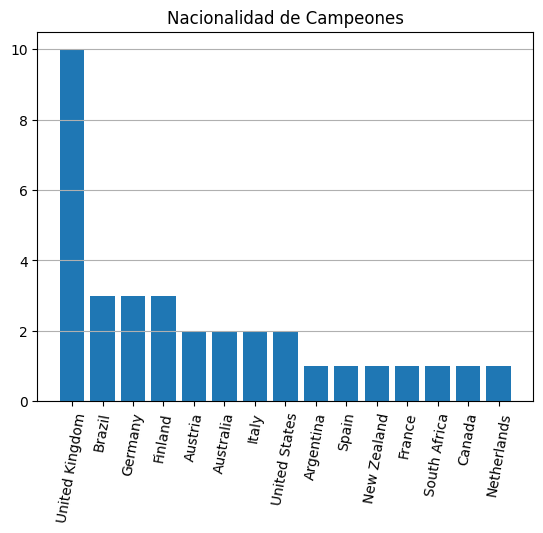

In [9]:
#Proveniencia de los corredores campeones
champions_df = df[df['Championships'] > 0]
counts = champions_df.value_counts("Nationality")
counts = counts[counts > 0]
plt.bar(x=counts.index,height=counts.values)
plt.xticks(rotation=80)
plt.grid(True,axis="y")
plt.title("Nacionalidad de Campeones")

plt.show()


___
De este grafico vemos que los paises mas ganadores son:
- Reino Unido
- Brasil
- Alemania
- Finlandia
___


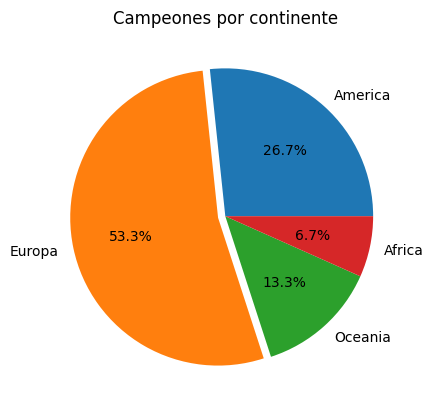

In [10]:
#Analizemos mas grueso el origen, viendo el contienete al que pertencen
mundo = {
    "America":["Brazil","Argentina","United States","Canada"],
    "Europa":["United Kingdom","Germany","Finland","Austria","Italy","Spain","France","Netherlands"],
    "Oceania":["New Zealand","Australia"],
    "Africa":["South Africa"]
}
v = {
    "America":0,
    "Europa":0,
    "Oceania":0,
    "Africa":0
}
for country in counts.index:
    for continent in mundo:
        if country in mundo[continent]:
            v[continent] = v[continent] + 1 

#Check para saber si falto alguno

n_v = 0
for continent in v:
    n_v = n_v + v[continent]

if n_v != len(counts.index):
    raise ValueError


#Mostraos con grafico de torta

explode = [0.05 if x == max(v.values()) else 0 for x in v.values()]

plt.pie(v.values(), labels=v.keys(), autopct='%1.1f%%', explode=explode)
plt.title("Campeones por continente")
plt.show()

___
Este grafico nos muestra el claro predominio de Europa, el cual es un argumento potencialmente valido en la discusion actual respecto de las posibilidades de los pilotos no europeos
___

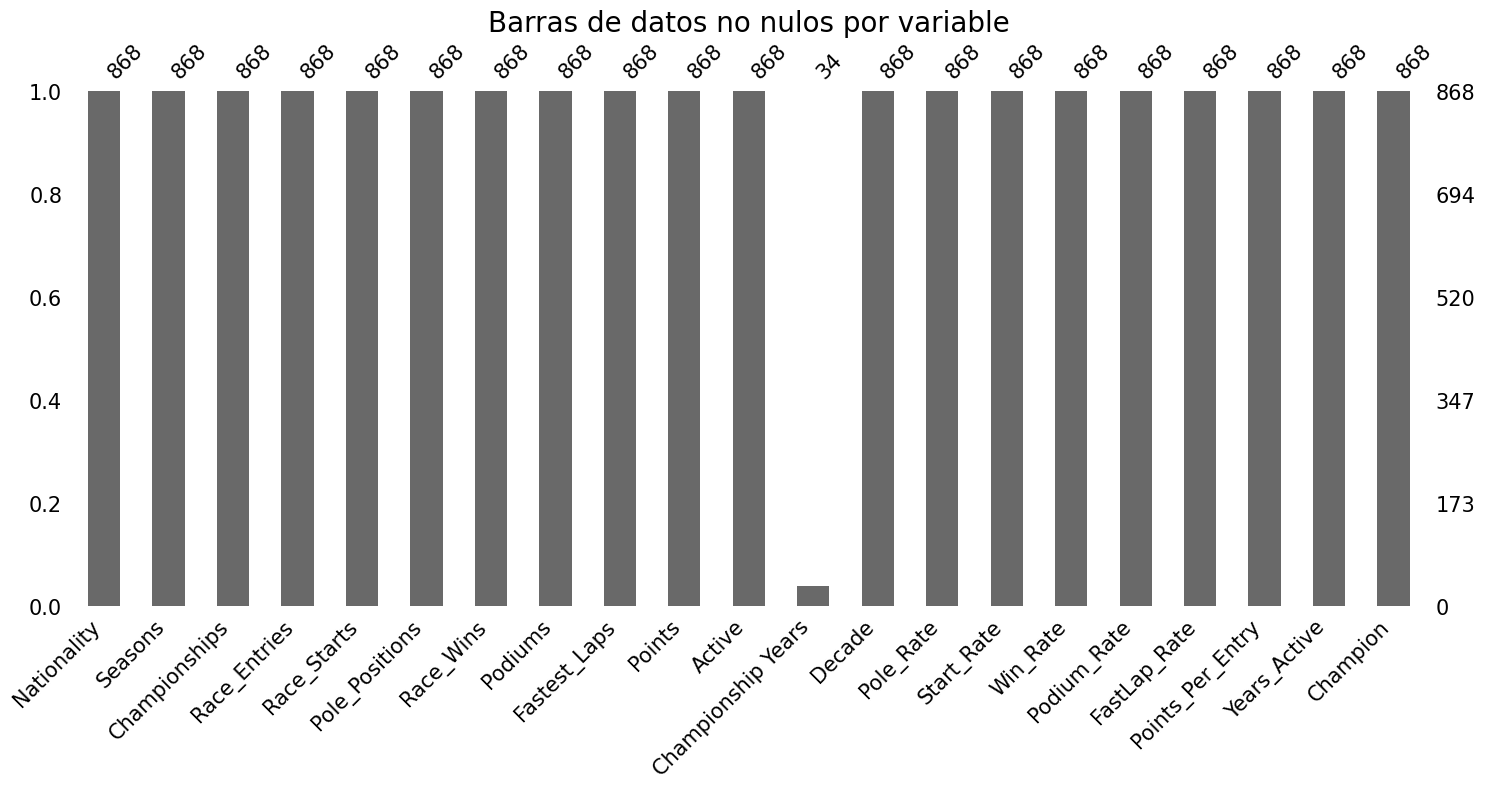

In [11]:
#Veamos los valores faltantes del dataset
msno.bar(df, fontsize=15, figsize=(15,8))
plt.title("Barras de datos no nulos por variable", fontsize=20)
plt.tight_layout()
plt.show()

___
Resulta interesante ver que en este dataset, la mayoria de los datos estan completos, menos `Championship Years`. La intuicion indica que este es vacio cuando el piloto no ha sido campeon. Intentaremos verificar si es asi.
___

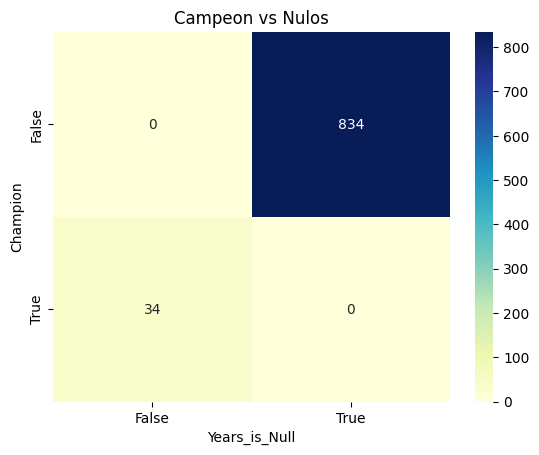

In [141]:
# Columna si es nulo o no
df['Years_is_Null'] = df['Championship Years'].isna()

pivot = df.groupby(['Champion', 'Years_is_Null']).size().unstack(fill_value=0)

sns.heatmap(pivot, annot=True, fmt="d", cmap="YlGnBu",)
plt.title("Campeon vs Nulos")
plt.show()

___
Se observa que claramente, la ausencia de `Championship_Years` (Eje X en true) se da cuando `Champion` es False (Eje Y en False).  
Esto indica que, efectivamente, la falta del campo se debe a que el piloto no ha sido campeon. Podriamos catalogar este ausencia dentro de MAR, ya que la ausencia depende de otra columna.
___

In [20]:
#Analisis de outliers
#La intencion es calcular los cuartiles, y usando el criterio visto en clase, ver la proporcion de outliers.

numeric_df = df.select_dtypes(include=['number'])
Q1 = numeric_df.quantile(0.25)
Q3 = numeric_df.quantile(0.75)
IQR = Q3-Q1
outliers_iqr = (numeric_df < (Q1 - 1.5 * IQR)) | (numeric_df > (Q3 + 1.5 * IQR))
print(outliers_iqr.mean()*100)


Championships        3.917051
Race_Entries        13.940092
Race_Starts         13.709677
Pole_Positions      12.211982
Race_Wins           13.018433
Podiums             24.769585
Fastest_Laps        15.668203
Points              16.589862
Decade               4.262673
Pole_Rate           12.211982
Start_Rate          10.368664
Win_Rate            13.018433
Podium_Rate         24.769585
FastLap_Rate        15.668203
Points_Per_Entry    15.898618
Years_Active         4.493088
dtype: float64


___
Tras ver los outliers, podemos decir que el dataset tiene una gran proporcion de los mismos. Pero considero que nuevamente debido a la naturaleza del deporte, en el que se rotan los pilotos y los ganadores son pocos, tiene sentido ver cosas de este tipo
___

Disclaimer, se hizo uso de IA unicamente como soporte para el uso de Pandas y estilizacion de graficos.